<a href="https://colab.research.google.com/github/ShahidNauman/heart-disease-prediction/blob/main/heart-disease-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction

## Objective:

Build a model to predict whether a person is at risk of heart disease based on their health data.

## Dataset:

Heart Disease UCI Dataset (available on Kaggle)

### 1.   Load the Heart Disease UCI dataset.

In [281]:
import os
from google.colab import userdata
import pandas as pd

# Ignore FutureWarnings in Cell 143
pd.set_option("future.no_silent_downcasting", True)

dataset_path = "data/heart_disease_uci.csv"

if not os.path.exists(dataset_path):
    # Get the Kaggle API Token from Colab Secrets to access the dataset
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    # Download and Extract the dataset from Kaggle
    os.system("mkdir -p data")
    os.system("kaggle datasets download -d redwankarimsony/heart-disease-data -p data")
    os.system("unzip -o data/heart-disease-data.zip -d data")
    print(f"[INFO] Downloaded dataset to: {dataset_path}")
else:
    print(f"[INFO] Dataset already available at: {dataset_path}")

# Load the dataset
df = pd.read_csv(dataset_path)
df.head()

[INFO] Dataset already available at: data/heart_disease_uci.csv


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 2.   Clean the dataset (handle missing values if any).

In [282]:
import numpy as np

# 1. Replace "?" with proper NaN
total_qmarked = (df == "?").sum().sum()
if total_qmarked > 0:
    df.replace("?", np.nan, inplace=True)
    print(f"[INFO] Replaced {total_qmarked} values with proper NaN.")

In [283]:
# 2. Inspect Missing Values
total_missing = df.isnull().sum().sum()
if total_missing > 0:
    print(f"\n[INFO] {total_missing} missing values found. Imputing...")

    # Simple Imputation (Recommended for ML)

    # A. Numeric Columns → Median
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  - '{col}' filled with median ({median_val})")

    # B. Categorical Columns → Mode
    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  - '{col}' filled with mode ({mode_val})")


[INFO] 1759 missing values found. Imputing...
  - 'id' filled with median (460.5)
  - 'age' filled with median (54.0)
  - 'trestbps' filled with median (130.0)
  - 'chol' filled with median (223.0)
  - 'thalch' filled with median (140.0)
  - 'oldpeak' filled with median (0.5)
  - 'ca' filled with median (0.0)
  - 'num' filled with median (1.0)
  - 'sex' filled with mode (Male)
  - 'dataset' filled with mode (Cleveland)
  - 'cp' filled with mode (asymptomatic)
  - 'fbs' filled with mode (False)
  - 'restecg' filled with mode (normal)
  - 'exang' filled with mode (False)
  - 'slope' filled with mode (flat)
  - 'thal' filled with mode (normal)


In [284]:
# 3. Create a Mapping Dictionary
severity_column = "num"
severity_labels = ["Healthy", "Mild", "Moderate", "Severe", "Critical"]

df["severity"] = df[severity_column].map({k: v for k, v in enumerate(severity_labels)})
df.drop(columns=[severity_column]).head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,severity
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,Healthy
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,Moderate
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,Mild
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,Healthy
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,Healthy


### 3.   Perform Exploratory Data Analysis (EDA) to understand trends.

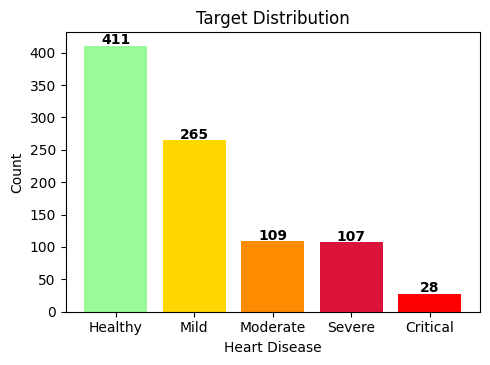

In [285]:
import seaborn as sns
import matplotlib.pyplot as plt

severity_palette = ["palegreen", "gold", "darkorange", "crimson", "red"]

# Check Target Variable Distribution
# - Shows class imbalance, important for ML.

fig, ax = plt.subplots(figsize=(5, 3.75))
counts = df[severity_column].value_counts().sort_index()
ax.bar(
    severity_labels,
    counts.to_numpy(),
    color=severity_palette,
)
ax.set_title("Target Distribution")
ax.set_xlabel("Heart Disease")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

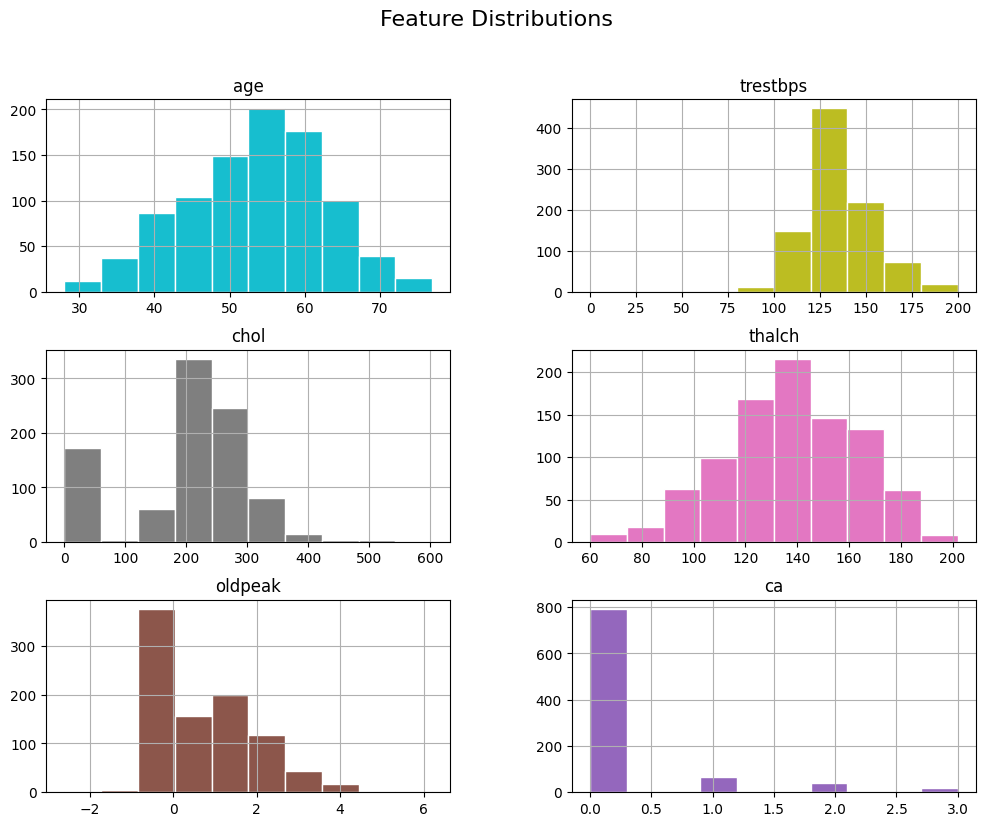

In [286]:
# Univariate Analysis (Single Feature Trends)
# Key observations:
# - Age distribution
# - Cholesterol levels
# - Resting BP spread

colors = plt.cm.tab10_r.colors
axes = df.drop(columns=["id", severity_column]).hist(figsize=(12, 9), edgecolor="white")

for ax, color in zip(axes.flatten(), colors):
    for patch in ax.patches:
        patch.set_facecolor(color)

plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

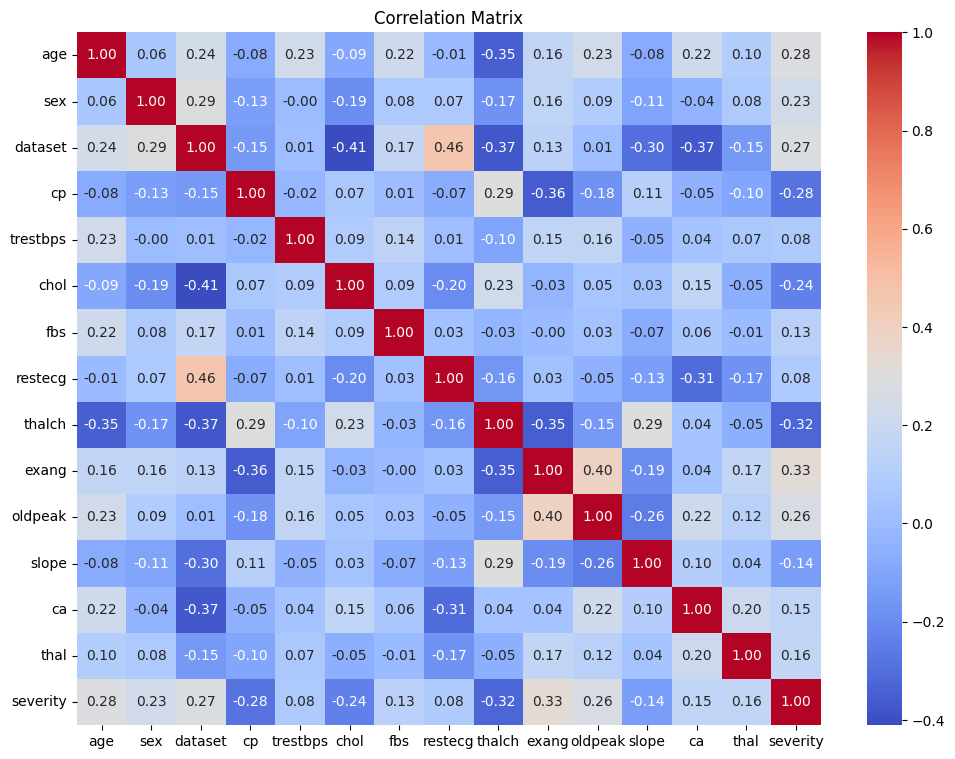

In [287]:
# Correlation Matrix (Heatmap)
# Helps identify:
# - Which features strongly relate to heart disease
# - Multicollinearity between features

from sklearn.preprocessing import LabelEncoder

df_encoded = df.drop(columns=["id", severity_column]).copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12, 9))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### Relationship Plots (Key Trends with Target)

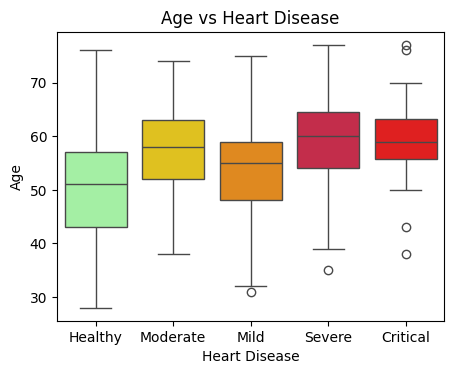

In [288]:
# Age vs Heart Disease
plt.figure(figsize=(5, 3.75))
sns.boxplot(
    x="severity",
    y="age",
    data=df,
    hue="severity",
    palette=severity_palette,
)
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

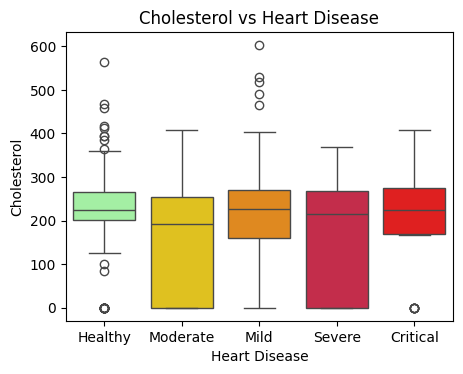

In [289]:
# Cholesterol vs Target
plt.figure(figsize=(5, 3.75))
sns.boxplot(
    x="severity",
    y="chol",
    data=df,
    hue="severity",
    palette=severity_palette,
    legend=False,
)
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.show()

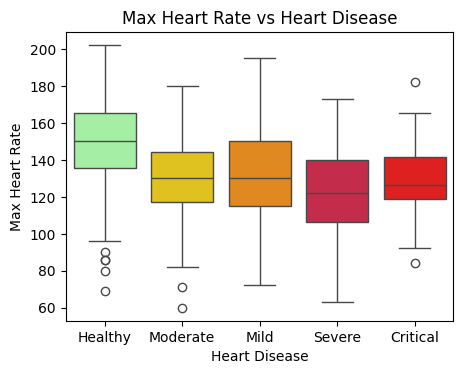

In [290]:
# Max Heart Rate vs Disease
plt.figure(figsize=(5, 3.75))
sns.boxplot(
    x="severity",
    y="thalch",
    data=df,
    hue="severity",
    palette=severity_palette,
    legend=False,
)
plt.title("Max Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate")
plt.show()

#### Categorical Feature Analysis

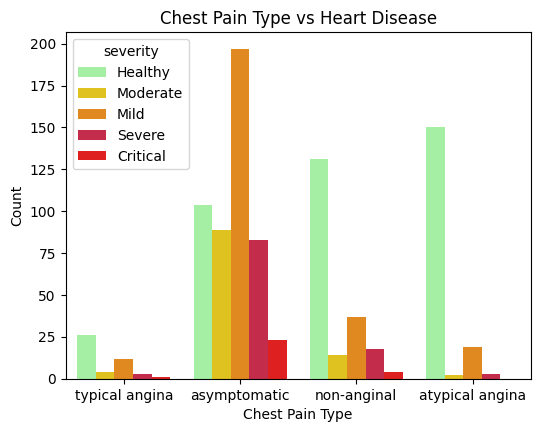

In [291]:
# Chest Pain Type (cp)
# Reveals which chest pain types correlate with disease

plt.figure(figsize=(6, 4.5))
sns.countplot(x="cp", hue="severity", data=df, palette=severity_palette)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

#### Feature Importance Insight (Correlation Bar Chart)

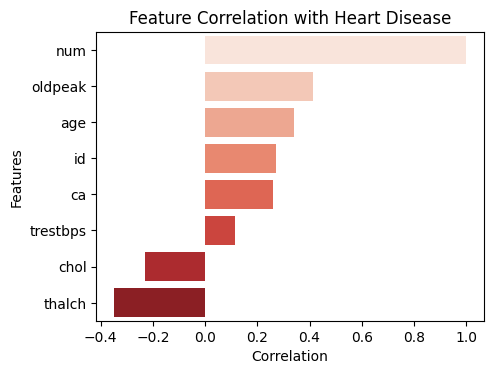

In [292]:
# Shows strongest predictors of heart disease.
corr_target = (
    df.select_dtypes(include="number")
    .corr()[severity_column]
    .sort_values(ascending=False)
)

plt.figure(figsize=(5, 3.75))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    hue=corr_target.index,
    palette="Reds",
    legend=False,
)

plt.title("Feature Correlation with Heart Disease")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

### 4.   Train a classification model (Logistic Regression or Decision Tree)

In [293]:
# Step 1: Prepare Features & Target
from sklearn.model_selection import train_test_split

severity_column = "num"

X = df.drop(
    columns=["id", "severity", severity_column]
    + [c for c in df.columns if c.startswith("dataset")]
)
y = df[severity_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (736, 13)
Test shape: (184, 13)


In [294]:
# Step 2: Encode Categorical Features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identify column types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (severity_column, StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [295]:
# Step 3: Logistic Regression Model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000))]
)

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [296]:
# Step 4: Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ]
)

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])


===== Logistic Regression =====
Accuracy: 0.5760869565217391

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.77      0.84      0.80        82
        Mild       0.48      0.57      0.52        53
    Moderate       0.30      0.14      0.19        22
      Severe       0.20      0.19      0.20        21
    Critical       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.35      0.35      0.34       184
weighted avg       0.54      0.58      0.55       184



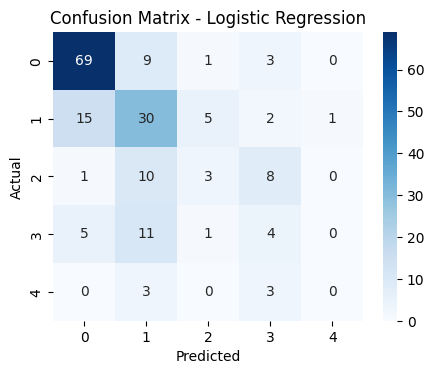


===== Decision Tree =====
Accuracy: 0.5163043478260869

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.71      0.84      0.77        82
        Mild       0.43      0.36      0.39        53
    Moderate       0.14      0.14      0.14        22
      Severe       0.18      0.19      0.19        21
    Critical       0.00      0.00      0.00         6

    accuracy                           0.52       184
   macro avg       0.29      0.31      0.30       184
weighted avg       0.48      0.52      0.49       184



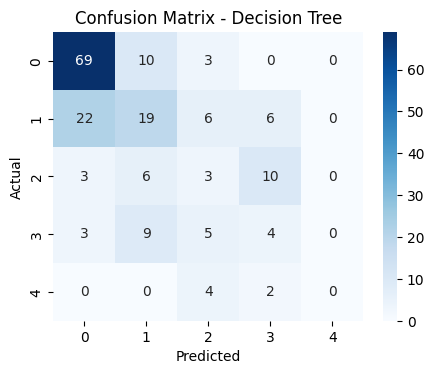

In [297]:
# Step 5: Evaluate Models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)

    print(f"\n===== {title} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(
        "\nClassification Report:\n",
        classification_report(
            y_test, y_pred, target_names=severity_labels, zero_division=0
        ),
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 3.75))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Evaluate both
evaluate_model(log_reg_pipeline, X_test, y_test, "Logistic Regression")
evaluate_model(dt_pipeline, X_test, y_test, "Decision Tree")

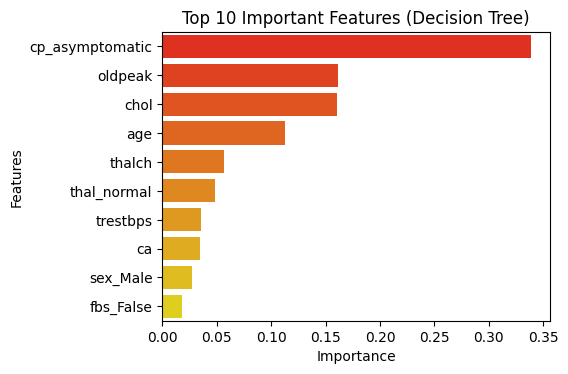

In [298]:
# Extract feature names after encoding
encoded_cat = (
    dt_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

all_features = list(num_cols) + list(encoded_cat)

importances = dt_pipeline.named_steps["model"].feature_importances_

feat_imp = (
    pd.Series(importances, index=all_features).sort_values(ascending=False).head(10)
)

plt.figure(figsize=(5, 3.75))
sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    hue=feat_imp.index,
    palette="autumn",
    legend=False,
)
plt.title("Top 10 Important Features (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [299]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report,
)

categorical_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop(
    columns=[
        c
        for c in df.columns
        if c.startswith("severity")
        or c.startswith("dataset")
        or c in ["id", severity_column]
    ]
)

y = df[severity_column]
y = (y > 0).astype(int)
feature_names = X.columns.tolist()

# Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
}

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")

    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring="accuracy")

    print(f"  Test Accuracy  : {acc:.4f}")
    print(f"  ROC-AUC Score  : {roc_auc:.4f}")
    print(f"  CV Accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(
        f"\n  Classification Report:\n{classification_report(y_test, y_pred, target_names=['No Disease', 'Disease'])}"
    )

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "accuracy": acc,
    }


--- Logistic Regression ---
  Test Accuracy  : 0.8424
  ROC-AUC Score  : 0.9032
  CV Accuracy    : 0.8125 ± 0.0208

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


--- Decision Tree ---
  Test Accuracy  : 0.7826
  ROC-AUC Score  : 0.8580
  CV Accuracy    : 0.7582 ± 0.0126

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.76      0.76      0.76        82
     Disease       0.80      0.80      0.80       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



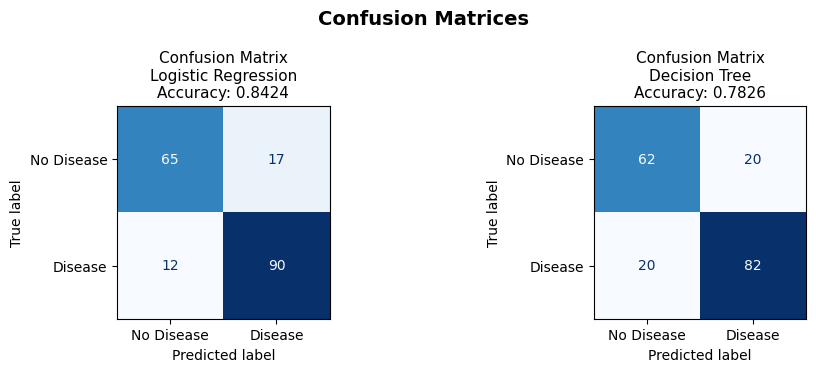

In [300]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 3.75))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No Disease", "Disease"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(
        f"Confusion Matrix\n{name}\nAccuracy: {res['accuracy']:.4f}", fontsize=11
    )
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

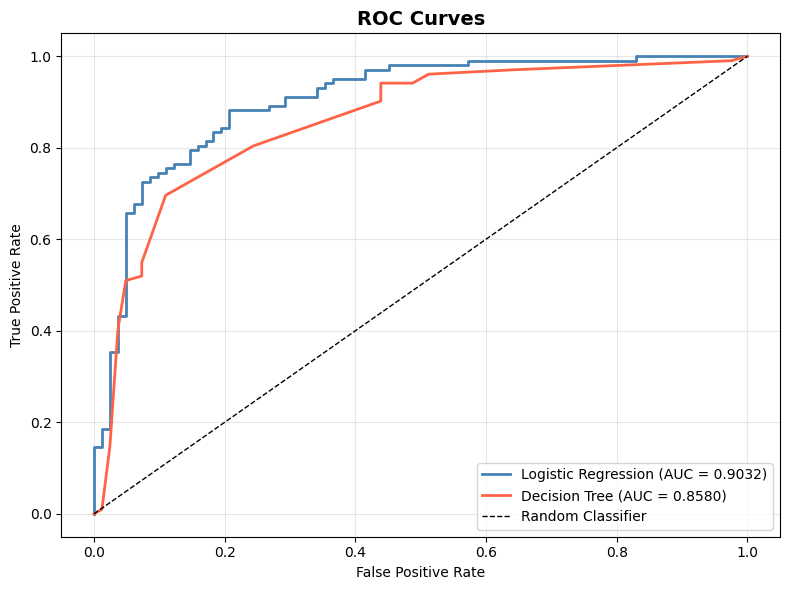

In [301]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "tomato"]
for (name, res), color in zip(results.items(), colors):
    ax.plot(
        res["fpr"],
        res["tpr"],
        color=color,
        lw=2,
        label=f"{name} (AUC = {res['roc_auc']:.4f})",
    )
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

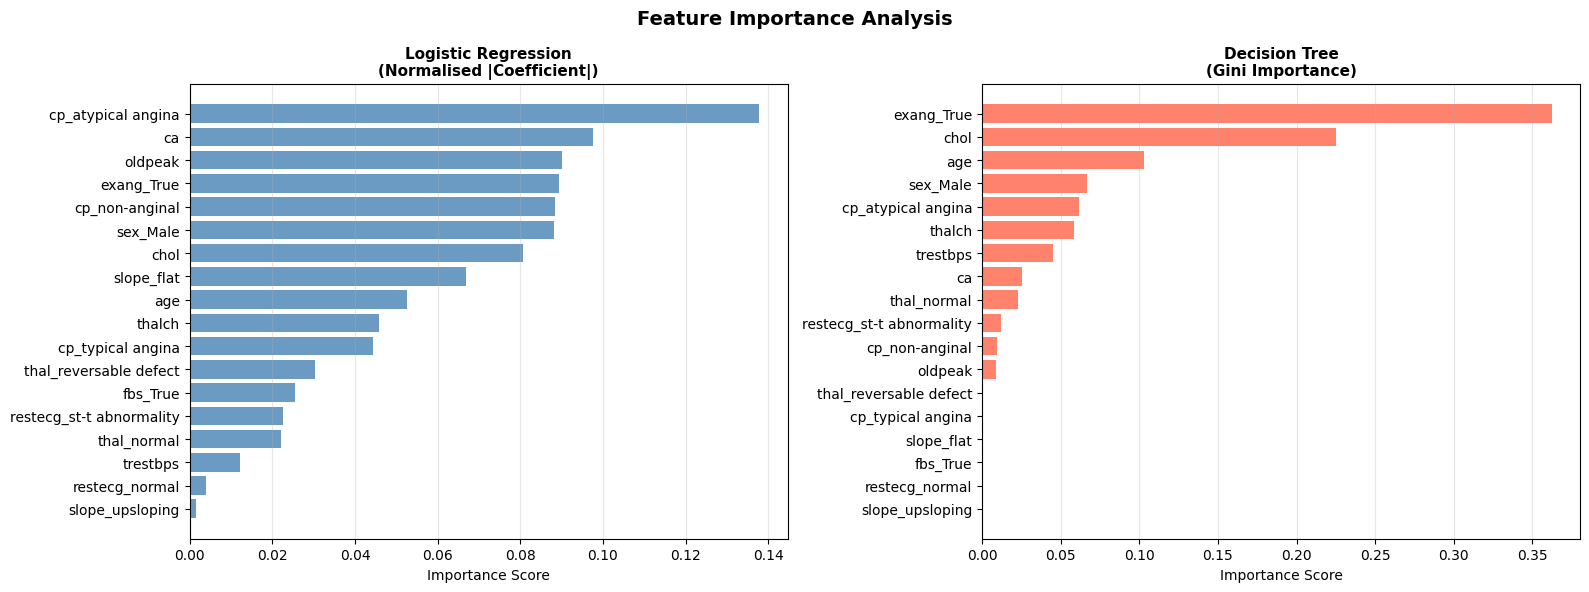

In [302]:
# Feature importance
# - Plot feature importances for both models side-by-side.

# Logistic Regression: absolute coefficients
lr_model = results["Logistic Regression"]["model"]
lr_importance = np.abs(lr_model.coef_[0])
lr_importance = lr_importance / lr_importance.sum()  # normalise

# Decision Tree: Gini importance
dt_model = results["Decision Tree"]["model"]
dt_importance = dt_model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, importance, title, color in zip(
    axes,
    [lr_importance, dt_importance],
    [
        "Logistic Regression\n(Normalised |Coefficient|)",
        "Decision Tree\n(Gini Importance)",
    ],
    ["steelblue", "tomato"],
):
    idx = np.argsort(importance)
    ax.barh(
        [feature_names[i] for i in idx],
        importance[idx],
        color=color,
        alpha=0.8,
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Importance Score")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [303]:
# Print top features
FEATURE_DESCRIPTIONS = {
    "age": "Age (years)",
    "sex": "Sex (1=Male, 0=Female)",
    "cp": "Chest Pain Type (0-3)",
    "trestbps": "Resting Blood Pressure (mmHg)",
    "chol": "Serum Cholesterol (mg/dl)",
    "fbs": "Fasting Blood Sugar >120 mg/dl",
    "restecg": "Resting ECG Results (0-2)",
    "thalach": "Max Heart Rate Achieved",
    "exang": "Exercise Induced Angina",
    "oldpeak": "ST Depression (Exercise vs Rest)",
    "slope": "Slope of Peak Exercise ST Segment",
    "ca": "Major Vessels Colored by Fluoroscopy",
    "thal": "Thalassemia (1=Normal, 2=Fixed, 3=Reversable)",
}

print("\nTop 5 Features (Logistic Regression):")
lr_df = pd.Series(lr_importance, index=feature_names).sort_values(ascending=False)
for feat, score in lr_df.head(5).items():
    print(f"  {feat:<12} {score:.4f}  — {FEATURE_DESCRIPTIONS.get(str(feat), '')}")

print("\nTop 5 Features (Decision Tree):")
dt_df = pd.Series(dt_importance, index=feature_names).sort_values(ascending=False)
for feat, score in dt_df.head(5).items():
    print(f"  {feat:<12} {score:.4f}  — {FEATURE_DESCRIPTIONS.get(str(feat), '')}")


Top 5 Features (Logistic Regression):
  cp_atypical angina 0.1378  — 
  ca           0.0975  — Major Vessels Colored by Fluoroscopy
  oldpeak      0.0901  — ST Depression (Exercise vs Rest)
  exang_True   0.0893  — 
  cp_non-anginal 0.0883  — 

Top 5 Features (Decision Tree):
  exang_True   0.3621  — 
  chol         0.2248  — Serum Cholesterol (mg/dl)
  age          0.1031  — Age (years)
  sex_Male     0.0666  — 
  cp_atypical angina 0.0618  — 


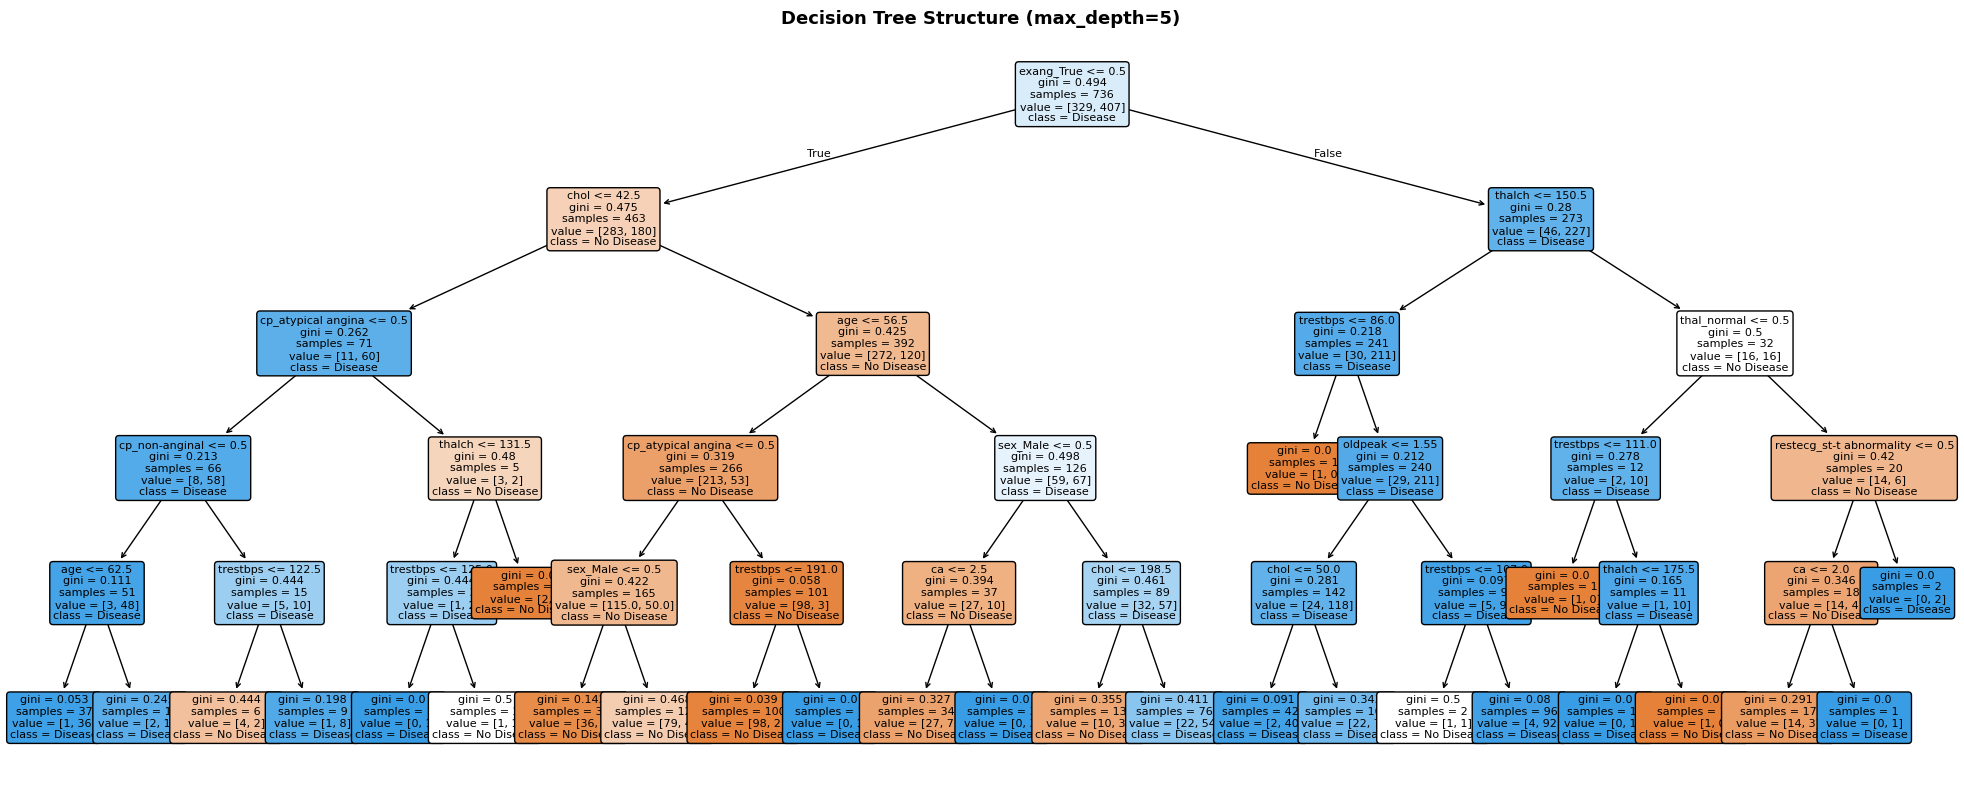

In [304]:
# Decision Tree visualisation
dt_model = results["Decision Tree"]["model"]
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision Tree Structure (max_depth=5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [305]:
# Final Summary
print("Summary:")
for name, res in results.items():
    print(f"  {name:<25} Accuracy={res['accuracy']:.4f}  ROC-AUC={res['roc_auc']:.4f}")

best = max(results, key=lambda k: results[k]["roc_auc"])
print(f"\n  Best model by ROC-AUC: {best}")

Summary:
  Logistic Regression       Accuracy=0.8424  ROC-AUC=0.9032
  Decision Tree             Accuracy=0.7826  ROC-AUC=0.8580

  Best model by ROC-AUC: Logistic Regression


### 5.   Evaluate using metrics: accuracy, ROC curve, and confusion matrix.

In [306]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.7826


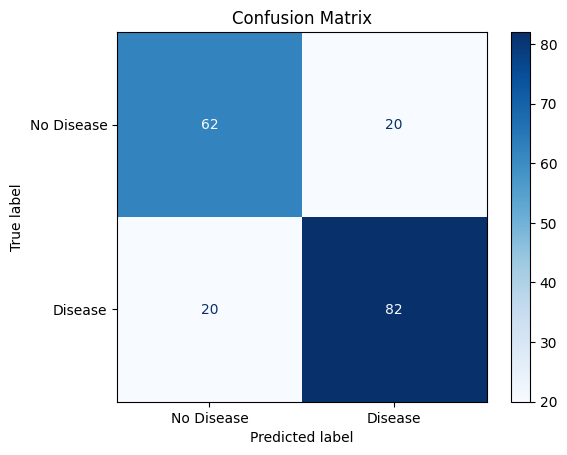

In [307]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

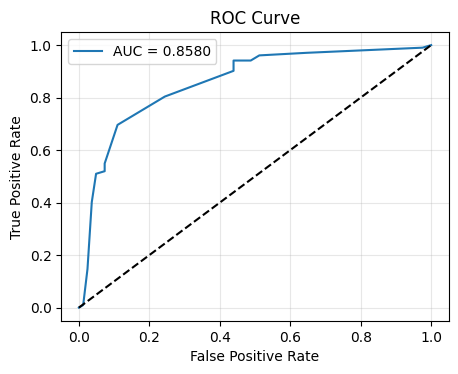

In [308]:
# OC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 3.75))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6.   Highlight important features affecting prediction.

In [309]:
# Decision Tree – Feature Importance
import pandas as pd

dt_importance_df = (
    pd.Series(dt_importance, index=feature_names)
    .sort_values(ascending=False)
)

print("Top 10 Important Features (Decision Tree):")
print(dt_importance_df.head(10))

Top 10 Important Features (Decision Tree):
exang_True                  0.362122
chol                        0.224770
age                         0.103149
sex_Male                    0.066613
cp_atypical angina          0.061811
thalch                      0.058369
trestbps                    0.044832
ca                          0.025592
thal_normal                 0.022949
restecg_st-t abnormality    0.011714
dtype: float64


In [310]:
# Logistic Regression – Coefficient Importance
lr_coef = pd.Series(lr_model.coef_[0], index=feature_names)
lr_coef_sorted = lr_coef.sort_values(key=np.abs, ascending=False)

print("Top 10 Important Features (Logistic Regression):")
print(lr_coef_sorted.head(10))

Top 10 Important Features (Logistic Regression):
cp_atypical angina   -0.765309
ca                    0.541772
oldpeak               0.500533
exang_True            0.495932
cp_non-anginal       -0.490656
sex_Male              0.489238
chol                 -0.448481
slope_flat            0.371497
age                   0.291553
thalch               -0.254967
dtype: float64


## Conclusion / Key Fact Findings

Feature importance analysis revealed that exercise-induced angina, chest pain type, ST depression, number of major vessels, age, and sex were the most influential predictors of heart disease. Both the Decision Tree and Logistic Regression models consistently identified these variables, reinforcing their clinical relevance. The alignment between models suggests robust predictive signals rather than model-specific artifacts.